In [3]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [4]:
# Dataset
X, y = make_moons(n_samples=300, noise=0.3, random_state=42)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0
)

N = len(X_train)

In [5]:
def bootstrap_sample(X, y):
    N = len(X)
    indices = np.random.choice(N, size=N, replace=True)
    return X[indices], y[indices], indices

fractions = []

for i in range(5):
    Xb, yb, idx = bootstrap_sample(X_train, y_train)
    unique_fraction = len(np.unique(idx)) / len(idx)
    fractions.append(unique_fraction)
    print(f"Sample {i+1}: fraction unique = {unique_fraction:.3f}")

print("\nMean fraction:", np.mean(fractions))
print("Expected ≈", 1 - 1/np.e)

Sample 1: fraction unique = 0.614
Sample 2: fraction unique = 0.643
Sample 3: fraction unique = 0.657
Sample 4: fraction unique = 0.595
Sample 5: fraction unique = 0.629

Mean fraction: 0.6276190476190476
Expected ≈ 0.6321205588285577


In [6]:
trees = []
accuracies = []

for i in range(5):
    Xb, yb, _ = bootstrap_sample(X_train, y_train)

    tree = DecisionTreeClassifier(max_depth=None, max_features='sqrt')
    tree.fit(Xb, yb)

    y_pred = tree.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    trees.append(tree)
    accuracies.append(acc)

    print(f"Tree {i+1} accuracy: {acc:.3f}")

print("\nAverage accuracy:", np.mean(accuracies))
print("Best accuracy:", np.max(accuracies))

Tree 1 accuracy: 0.856
Tree 2 accuracy: 0.767
Tree 3 accuracy: 0.811
Tree 4 accuracy: 0.878
Tree 5 accuracy: 0.789

Average accuracy: 0.8200000000000001
Best accuracy: 0.8777777777777778


In [13]:
def majority_vote(trees, X):
    preds = np.array([tree.predict(X) for tree in trees])
    
    final_preds = []
    for i in range(preds.shape[1]):
        counts = Counter(preds[:, i])
        final_preds.append(counts.most_common(1)[0][0])
    
    return np.array(final_preds)

# Ensemble prediction
y_ensemble = majority_vote(trees, X_test)
ensemble_acc = accuracy_score(y_test, y_ensemble)

print("Ensemble accuracy:", ensemble_acc)

if ensemble_acc > np.mean(accuracies):
    print("It is better than the average individual tree accuracy")
else:
    print("It is NOT better than the average individual tree accuracy")

if ensemble_acc > np.max(accuracies):
    print("It is better than the best individual tree accuracy")
else:
    print("It is NOT better than the best individual tree accuracy")

Ensemble accuracy: 0.8222222222222222
It is better than the average individual tree accuracy
It is NOT better than the best individual tree accuracy


In [14]:
B_values = [1, 5, 10, 25, 50, 100, 200]

ensemble_accs = []
rf_accs = []

for B in B_values:
    trees = []

    for _ in range(B):
        Xb, yb, _ = bootstrap_sample(X_train, y_train)
        tree = DecisionTreeClassifier(max_depth=None, max_features='sqrt')
        tree.fit(Xb, yb)
        trees.append(tree)

    # Ensemble accuracy
    y_pred = majority_vote(trees, X_test)
    ensemble_accs.append(accuracy_score(y_test, y_pred))

    # sklearn Random Forest
    rf = RandomForestClassifier(n_estimators=B, max_features='sqrt', random_state=0)
    rf.fit(X_train, y_train)
    rf_accs.append(accuracy_score(y_test, rf.predict(X_test)))

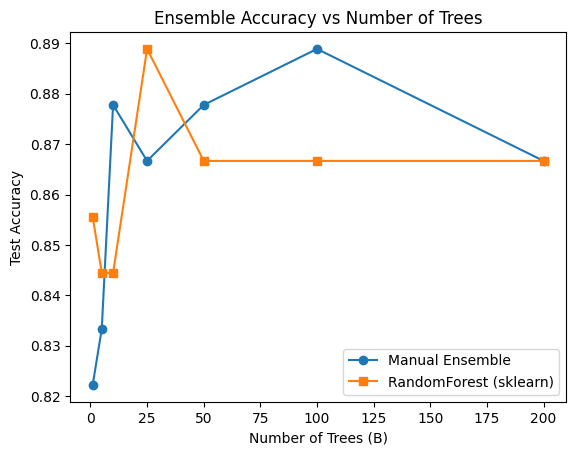

In [15]:
plt.plot(B_values, ensemble_accs, marker='o', label='Manual Ensemble')
plt.plot(B_values, rf_accs, marker='s', label='RandomForest (sklearn)')
plt.xlabel('Number of Trees (B)')
plt.ylabel('Test Accuracy')
plt.legend()
plt.title('Ensemble Accuracy vs Number of Trees')
plt.show()

# Discussion

We use the variance formula for an ensemble of $B$ models:
$
\mathrm{Var}(\bar{f}) = \rho \sigma^2 + \frac{1 - \rho}{B}\sigma^2
$
where:
- $\sigma^2$ = variance of an individual model  
- $\rho$ = correlation between models  

---

## (i) Which term is reduced by increasing $B$?

The second term:
$
\frac{1 - \rho}{B}\sigma^2
$

As $B$ increases, this term decreases and approaches zero.  
This represents the reduction of variance due to averaging multiple models.

---

## (ii) Role of `max_features='sqrt'`

Using `max_features='sqrt'` reduces the correlation $\rho$ between trees.

- Each split considers only a random subset of features  
- Trees become more diverse  
- They are less likely to make the same errors  

This helps reduce the first term:
$
\rho \sigma^2
$

---

## (iii) Why does the ensemble accuracy plateau?

Even as $B \to \infty$, the variance becomes:
$
\mathrm{Var}(\bar{f}) \to \rho \sigma^2
$

This term does not depend on $B$, so it cannot be reduced by adding more trees.

Therefore:
- Increasing $B$ reduces variance only up to a point  
- The remaining error is due to correlation between trees  

This is why the test accuracy improves initially but eventually plateaus.
